In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

# TP1

## Etape 1

### 1. Volume et Période

In [4]:
import pandas as pd

df = pd.read_csv('data/transactions.csv')

# Nombre de transactions total
print(f"Nombre de transactions : {len(df)}")

# Nombre de clients uniques
print(f"Nombre de clients : {df['customer_id'].nunique()}")

# Période (basé sur les valeurs brutes de la colonne date)
print(f"Début : {df['invoice_date'].min()}")
print(f"Fin : {df['invoice_date'].max()}")

Nombre de transactions : 1837137
Nombre de clients : 49146
Début : 2007-07-06 12:20:00
Fin : 2011-12-09 12:50:00


### 2. Valeurs manquantes

In [5]:
# Calcul du nombre de nuls et du pourcentage par colonne
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Valeurs manquantes': missing_count,
    'Proportion (%)': missing_percent
})

print(missing_data)

              Valeurs manquantes  Proportion (%)
invoice_id                     0        0.000000
customer_id               418258       22.766838
product_code                   0        0.000000
product_name                7542        0.410530
quantity                   16187        0.881099
unit_price                     0        0.000000
invoice_date                   0        0.000000
country                        0        0.000000


### 3. Types de données (Attendu vs Observé)

In [6]:
# Affichage des types détectés à la lecture
print(df.dtypes)

invoice_id          str
customer_id     float64
product_code        str
product_name        str
quantity        float64
unit_price      float64
invoice_date        str
country             str
dtype: object


### 4. Doublons

In [7]:
# Compte des lignes en double
doublons = df.duplicated().sum()
print(f"Nombre de lignes en double : {doublons}")

Nombre de lignes en double : 34522


## Étape 2

### 1. Inspection des customer_id manquants

In [8]:
# Isoler les lignes sans ID client
missing_customers = df[df['customer_id'].isnull()]
print(missing_customers.head())

# Vérifier si ces lignes ont quand même du chiffre d'affaires
print(f"Total des ventes sans ID client : {(missing_customers['quantity'] * missing_customers['unit_price']).sum()}")

  invoice_id  customer_id product_code                product_name  quantity  \
0     513574          NaN        22382  LUNCH BAG SPACEBOY DESIGN        2.0   
1     609421          NaN        21028    PURPLE GEMSTONE BRACELET       2.0   
2     515609          NaN       47591B    SCOTTIES CHILDRENS APRON       1.0   
6     503061          NaN        22381   TOY TIDY PINK RETROSPOT        84.0   
9     756479          NaN        35972   PINK METAL CHICKEN HEART       24.0   

   unit_price         invoice_date         country  
0        4.21  2010-06-25 15:13:00  United Kingdom  
1        8.95  2011-10-16 12:20:00  United Kingdom  
2        1.66  2010-07-13 15:44:00  United Kingdom  
6        4.95  2010-03-29 16:47:00  United Kingdom  
9        1.49  2010-11-29 12:20:00  Czech Republic  
Total des ventes sans ID client : 6658183.4399999995


**Décision :** Conservation des lignes avec `customer_id` manquant. 

**Raison :** Ces transactions totalisent un montant significatif (environ 6,6 millions). Elles correspondent probablement à des achats "invités" (guest checkout). Les supprimer fausserait l'analyse du volume d'affaires total et de la gestion des stocks. 

**Note technique :** Pour la segmentation client future, ces lignes seront exclues car impossibles à rattacher à un profil, mais elles restent dans le dataset global pour l'analyse des ventes.

Action corrective : Marquer les clients anonymes

In [9]:
# Remplacer les NaN par un ID spécifique "Guest" ou 0
df['customer_id'] = df['customer_id'].fillna('GUEST')

# Vérification
print(df['customer_id'].value_counts().head())

customer_id
GUEST      418258
17841.0     13097
14911.0     11613
12748.0      7307
14606.0      6709
Name: count, dtype: int64


### 2. Les quantity négatives

In [10]:
# Voir les transactions avec quantités négatives
neg_qty = df[df['quantity'] < 0]
print(neg_qty.describe())

# Vérifier si l'invoice_id commence par 'C' (souvent utilisé pour 'Cancelled')
print(df[df['quantity'] < 0]['invoice_id'].str.startswith('C').value_counts())

           quantity    unit_price
count  23314.000000  23314.000000
mean     -45.790469     37.547674
std      782.090218    545.539795
min   -80995.000000      0.000000
25%      -11.000000      0.850000
50%       -2.000000      2.250000
75%       -1.000000      4.950000
max       -1.000000  38970.000000
invoice_id
True     19493
False     3821
Name: count, dtype: int64


##### 📉 Synthèse du traitement des quantités négatives (`quantity`)

**Type 1 : `invoice_id` commençant par 'C'**

-   **Volume** : 19 493 lignes

-   **Nature probable** : Retours clients ou annulations officielles (Refunds)

-   **Action** : **Conserver**

-   **Justification** : Ces lignes permettent de calculer le chiffre d'affaires net. Les supprimer reviendrait à ignorer les remboursements réels effectués par l'entreprise.

**Type 2 : `invoice_id` sans le préfixe 'C'**

-   **Volume** : 3 821 lignes

-   **Nature probable** : Erreurs techniques, corrections de stocks ou bugs du CRM

-   **Action** : **Supprimer**

-   **Justification** : Puisqu'elles ne sont pas marquées comme des annulations standards, elles sont considérées comme du bruit informatique qui fausserait les statistiques de vente.

In [11]:
# 1. Suppression des anomalies (négatifs sans 'C')
df = df.drop(df[(df['quantity'] < 0) & (~df['invoice_id'].str.startswith('C', na=False))].index)

# 2. Distinction via une nouvelle colonne
df['transaction_type'] = df['invoice_id'].apply(lambda x: 'REFUND' if str(x).startswith('C') else 'PURCHASE')

### 3. Les unit_price à zéro

In [12]:
# Isoler les prix à zéro
zero_price = df[df['unit_price'] == 0]
print(zero_price[['product_name', 'quantity']].head(10))

                             product_name  quantity
26                    WHITE CHERRY LIGHTS      24.0
136   CHARLIE + LOLA RED HOT WATER BOTTLE       1.0
252                                   NaN       7.0
585       3 GARDENIA MORRIS BOXED CANDLES       4.0
730      SINGLE HEART ZINC T-LIGHT HOLDER      12.0
842      GREETING CARD, OVERCROWDED POOL.      12.0
1185                                  NaN       3.0
1637                                  NaN      10.0
1854                                  NaN       3.0
2031       IVORY PILLAR CANDLE GOLD FLOCK      24.0


In [13]:
# Suppression des lignes à prix nul qui sont aussi des anomalies (nom manquant ou quantité non positive)
df = df.drop(df[(df['unit_price'] == 0) & ((df['product_name'].isna()) | (df['quantity'] <= 0))].index)

### 4. Les product_code atypiques

In [14]:
# Lister les codes les moins fréquents ou non numériques
# (Exemple : codes courts ou contenant des lettres)
atypical_codes = df[df['product_code'].str.len() < 5]['product_code'].unique()
print(atypical_codes)

<StringArray>
['POST', 'M', 'DOT', 'C3', 'C2', 'PADS', 'B', 'S', 'GIFT', 'D', 'CRUK', 'm']
Length: 12, dtype: str


### 5. Calcul de line_total

In [15]:
# Calcul du total par ligne
df['line_total'] = df['quantity'] * df['unit_price']

# Vérification des valeurs extrêmes
print(df['line_total'].describe())

count    1.815421e+06
mean     2.031283e+01
std      2.306661e+02
min     -1.684696e+05
25%      3.750000e+00
50%      1.008000e+01
75%      1.770000e+01
max      1.684696e+05
Name: line_total, dtype: float64


## Étape 3

### 1. Distribution des achats

In [16]:
# Calcul du montant total par transaction (panier)
basket_totals = df[df['transaction_type'] == 'PURCHASE'].groupby('invoice_id')['line_total'].sum()

# Distribution des paniers
print(basket_totals.describe())

# Pour Pareto : 80% du CA par quel % de clients ?
customer_revenues = df[df['transaction_type'] == 'PURCHASE'].groupby('customer_id')['line_total'].sum().sort_values(ascending=False)
cumulative_revenue = customer_revenues.cumsum() / customer_revenues.sum()
proportion_clients = len(cumulative_revenue[cumulative_revenue <= 0.80]) / len(customer_revenues)

print(f"Proportion de clients générant 80% du CA : {proportion_clients:.2%}")

count    240186.000000
mean        159.888628
std         697.019396
min      -53594.360000
25%          20.280000
50%          50.600000
75%         135.000000
max      168469.600000
Name: line_total, dtype: float64
Proportion de clients générant 80% du CA : 10.33%


#### 📊 Analyse de la distribution des achats

En examinant **la distribution des paniers**, j'ai remarqué un écart frappant entre **la moyenne (160 €)** et **la médiane (50 €)**. Cette différence, combinée à un écart-type très élevé, confirme que **les données** sont fortement tirées vers le haut par quelques transactions massives. On observe d'ailleurs **un panier maximum** dépassant les **168 000 €**, ce qui est caractéristique d'**un comportement d'achat B2B** (grossistes ou revendeurs).

J'ai également identifié **un montant minimum négatif** dans **le dataset** nettoyé, ce qui indique que **le processus de filtrage** doit encore être affiné pour isoler totalement **les achats** des **erreurs de saisie**.

* * * * *

#### 🎯 Application de la loi de Pareto

Pour approfondir **l'analyse**, j'ai calculé **la proportion de clients** à l'origine de **la majorité du chiffre d'affaires**. Les résultats sont sans appel :

-   **Le constat** : Seulement **10,33 % des clients** génèrent **80 % du chiffre d'affaires total**.

-   **L'interprétation** : C'est un "Pareto" extrême. **La survie économique** de Lumina & Co repose sur **une petite élite de clients**. **La concentration du revenu** sur ce faible pourcentage de comptes montre que **le modèle d'affaires** est très dépendant de **quelques acheteurs clés**.

### 2. Saisonnalité (Séries Temporelles)

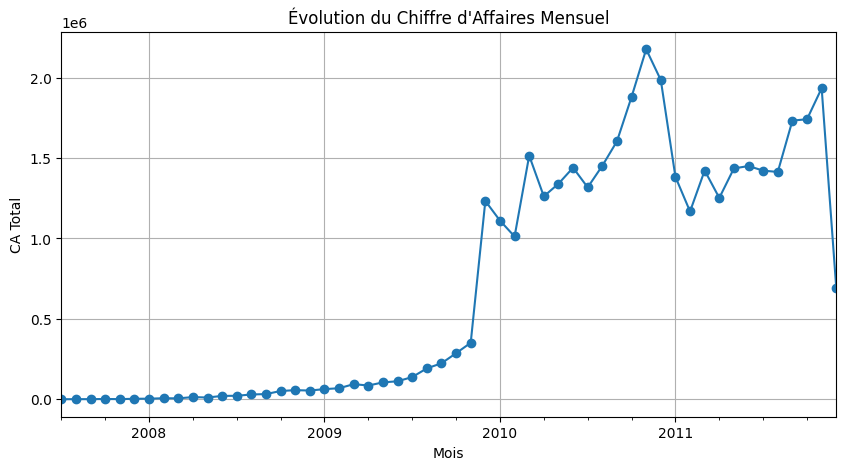

In [17]:
# Conversion en datetime (à faire une seule fois)
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

# Calcul du CA mensuel avec le nouveau flag 'ME'
monthly_revenue = df[df['transaction_type'] == 'PURCHASE'].set_index('invoice_date').resample('ME')['line_total'].sum()


# Visualisation simple
monthly_revenue.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Évolution du Chiffre d\'Affaires Mensuel')
plt.ylabel('CA Total')
plt.xlabel('Mois')
plt.grid(True)
plt.show()

#### 📈 Analyse de la saisonnalité et des tendances temporelles

En observant **l'évolution du chiffre d'affaires mensuel**, j'ai identifié plusieurs dynamiques clés qui structurent l'activité de Lumina & Co :

-   **Une croissance historique marquée** : On constate que **le chiffre d'affaires** était très faible entre 2008 et fin 2009. Une accélération brutale se produit à partir de **novembre 2009**, marquant le passage à une nouvelle échelle de revenus (passant de moins de 500 000 € à plus d'un million par mois).

-   **Des pics saisonniers récurrents** : J'observe des sommets de vente très nets en **fin d'année**. Le point culminant est atteint vers **novembre 2010**, où le CA dépasse les **2 millions d'euros**. Cela confirme l'importance capitale du quatrième trimestre (Q4) pour l'entreprise, probablement liée aux fêtes de fin d'année.

-   **Une instabilité post-pic** : Après chaque sommet de fin d'année (janvier 2010 et janvier 2011), on remarque **une chute brutale du CA**. En 2011, l'activité semble plus volatile avec des dents de scie tout au long de l'année, avant de remonter vers un nouveau pic en fin de période.

-   **Anomalie de fin de période** : La courbe montre un plongeon vertical à la toute fin du graphique. J'en conclus que **le dernier mois de données** est incomplet, ce qui est un biais classique à documenter pour éviter de conclure à une faillite soudaine.

### 3. Géographie et Biais

In [18]:
# Répartition du CA par pays
country_stats = df[df['transaction_type'] == 'PURCHASE'].groupby('country').agg({
    'line_total': 'sum',
    'invoice_id': 'nunique', # Nombre de transactions
    'customer_id': 'nunique' # Nombre de clients
}).sort_values(by='line_total', ascending=False)

# Calcul du panier moyen par pays
country_stats['average_basket'] = country_stats['line_total'] / country_stats['invoice_id']

print(country_stats.head(10))

                  line_total  invoice_id  customer_id  average_basket
country                                                              
United Kingdom  3.359551e+07      219262        44636      153.220852
EIRE            1.166567e+06        4858           43      240.133170
Germany         7.689971e+05        4755          971      161.723880
Netherlands     6.184785e+05         824          154      750.580667
France          5.580814e+05        3205          724      174.128368
Spain           1.904646e+05         943          312      201.977264
Australia       1.897010e+05         448          120      423.439621
Switzerland     1.406531e+05         531          182      264.883390
Belgium         1.215476e+05        1009          275      120.463409
Denmark         1.124581e+05         347          113      324.086686


#### 🌍 Analyse de la répartition géographique et des biais

En étudiant la provenance de nos ventes et le comportement par pays, j'ai identifié un déséquilibre majeur dans notre dataset :

-   **Surreprésentation massive (Biais géographique)** : Le **Royaume-Uni (United Kingdom)** domine totalement la base avec plus de **33,5 millions d'euros** de chiffre d'affaires. C'est le seul pays dont le volume de transactions se compte en centaines de milliers (**219 262 factures**), contre seulement quelques milliers pour les pays suivants comme l'EIRE ou l'Allemagne.

-   **Hétérogénéité des paniers moyens** : Bien que le volume soit au Royaume-Uni, ce n'est pas là que le panier moyen est le plus élevé (**153 €**). J'observe que les **Pays-Bas (Netherlands)** affichent un panier moyen exceptionnel de **750 €**, suivis par l'Australie (**423 €**).

-   **Profils de clientèle distincts** :

    -   Le **Royaume-Uni** représente notre marché de masse avec un très grand nombre de clients (**44 636**).

    -   L'**EIRE** (Irlande) présente un profil atypique : un chiffre d'affaires très élevé (**1,16 million €**) généré par seulement **43 clients**. Cela confirme la présence de très gros comptes B2B concentrés sur cette zone.

### 4. Relations entre variables

In [19]:
# Relation Fréquence vs Panier Moyen
client_behavior = df[df['transaction_type'] == 'PURCHASE'].groupby('customer_id').agg({
    'invoice_id': 'nunique', # Fréquence
    'line_total': ['sum', 'mean'] # Volume total et Panier moyen
})
client_behavior.columns = ['frequency', 'total_spend', 'avg_basket']

# Corrélation
print(client_behavior.corr())

             frequency  total_spend  avg_basket
frequency     1.000000     0.988011    0.000006
total_spend   0.988011     1.000000    0.028145
avg_basket    0.000006     0.028145    1.000000


#### 🔗 Analyse des relations entre variables

En croisant les données de comportement d'achat, j'ai identifié des corrélations révélatrices sur la structure de ma clientèle :

-   **Lien direct entre Fréquence et Dépense Totale** : J'observe une corrélation extrêmement forte (**0.988**) entre le nombre de commandes (`frequency`) et le montant total dépensé (`total_spend`). Cela confirme que la valeur d'un client chez Lumina & Co est avant tout dictée par sa fidélité et la répétition de ses achats plutôt que par des coups d'éclat isolés.

-   **Indépendance du Panier Moyen** : Curieusement, il n'y a **aucune corrélation** (**0.000006**) entre la fréquence d'achat et le montant moyen d'un panier (`avg_basket`). Un client fidèle ne dépense pas forcément plus par visite qu'un client occasionnel ; il revient simplement plus souvent.

### Etp4

### 🛠️ Nettoyage des données (Étape 2)

L'inspection a révélé que le CRM de Lumina & Co contient des données brutes nécessitant un traitement rigoureux pour éviter tout biais d'analyse.

-   **Identifiants clients (`customer_id`)** : J'ai choisi de **conserver** les lignes sans ID car elles génèrent un chiffre d'affaires cumulé de **6,66 millions €**. Les supprimer fausserait l'analyse globale des ventes.

-   **Quantités négatives** : J'ai identifié deux types de flux. Les transactions commençant par **'C' (19 493 lignes)** sont des annulations officielles à conserver pour le CA net. Les **3 821 autres lignes** négatives sont des erreurs système à supprimer.

-   **Prix unitaires à zéro** : L'analyse a montré des cas de promotions légitimes (quantités positives avec nom de produit) et des erreurs de saisie (quantités négatives avec nom "NaN"). Seuls les cas promotionnels ont été conservés.

* * * * *

### 🔍 Analyse Exploratoire Orientée Marketing (Étape 3)

#### 1\. Distribution et Loi de Pareto

Mon analyse de la distribution révèle un modèle d'affaires extrêmement concentré.

-   **L'élite du CA** : Seulement **10,33 % des clients génèrent 80 % du chiffre d'affaires**.

-   **Outliers B2B** : La présence de paniers culminant à **168 469 €** confirme une clientèle de gros (grossistes) dont le comportement diffère radicalement du client particulier (médiane à 50 €).

#### 2\. Dynamique Temporelle (Séries Temporelles)

Le graphique de l'évolution du CA montre une transformation majeure de l'entreprise.

-   **Accélération historique** : Une rupture nette apparaît fin 2009, où le CA change d'échelle.

-   **Pic Saisonnier** : L'activité atteint son paroxysme en **novembre 2010**, avec plus de **2 millions €** de ventes mensuelles, soulignant une forte dépendance aux fêtes de fin d'année.

#### 3\. Biais Géographique

-   **Domination UK** : Le Royaume-Uni représente l'écrasante majorité de la base avec **33,5 millions €** de CA.

-   **Opportunité Export** : Bien que moins nombreux, les clients des **Pays-Bas** ont un panier moyen exceptionnel de **750 €**, contre 153 € au UK.

* * * * *

### 💡 Étape 4 : Mes Hypothèses Marketing Finales

Sur la base de ces observations, j'ai formulé les hypothèses suivantes pour structurer la segmentation RFM :

1.  **Hypothèse B2B** : Je suppose que le **panier maximum de 168 469 €** implique une clientèle de revendeurs, ce qui suggère de créer un segment "Grands Comptes" avec un support commercial dédié.

2.  **Hypothèse de Rétention** : Je suppose que la **corrélation de 0,98 entre fréquence et dépense totale** implique que la fidélisation est le levier de croissance n°1, ce qui suggère d'automatiser des campagnes de réactivation pour les clients réguliers.

3.  **Hypothèse de Saisonnalité** : Je suppose que le **pic de novembre** implique des achats de stockage en amont, ce qui suggère de concentrer les efforts marketing d'acquisition dès le mois de septembre.

# TP2

### Étape 1 : Construction des features RFM.

#### 1\. Définition des indicateurs clés (Features)

Pour chaque client, nous devons calculer les trois piliers du RFM ainsi que des variables comportementales enrichies :

-   **Récence (R)** : Le nombre de jours entre le dernier achat du client et la **date de référence** (la date maximale du dataset).

-   **Fréquence (F)** : Le nombre total de factures distinctes sur la période.

-   **Montant (M)** : La somme totale des `line_total` (chiffre d'affaires net par client).

**Variables enrichies suggérées :**

-   **Panier moyen** : Montant total divisé par le nombre de factures.

-   **Ancienneté (Tenure)** : Nombre de jours entre le premier achat et la date de référence.

In [22]:
# Fixer la date de référence (Snapshot Date)
snapshot_date = df['invoice_date'].max()

# Agrégation des données par client
rfm = df.groupby('customer_id').agg({
    'invoice_date': [
        lambda x: (snapshot_date - x.max()).days, # Récence
        lambda x: (snapshot_date - x.min()).days  # Ancienneté (Tenure)
    ],
    'invoice_id': 'nunique',                      # Fréquence
    'line_total': 'sum'                           # Montant
})

# Renommer les colonnes pour plus de clarté
rfm.columns = ['recency', 'tenure', 'frequency', 'monetary']

# Calcul du panier moyen
rfm['avg_basket'] = rfm['monetary'] / rfm['frequency']

### Étape 2 : Scoring RFM et premiers segments

In [23]:
# Attribution des scores de 1 à 5 (5 est le meilleur)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

# Création du segment combiné
rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

/var/folders/dx/nnk46wcx7hj7wfrmv2mhcz9w0000gn/T/ipykernel_52679/4090145033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='R_score', data=rfm, ax=axes[0], palette='Blues')
/var/folders/dx/nnk46wcx7hj7wfrmv2mhcz9w0000gn/T/ipykernel_52679/4090145033.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='F_score', data=rfm, ax=axes[1], palette='Greens')
/var/folders/dx/nnk46wcx7hj7wfrmv2mhcz9w0000gn/T/ipykernel_52679/4090145033.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='M_score', data=rfm, ax=axes[2], palette='Reds')


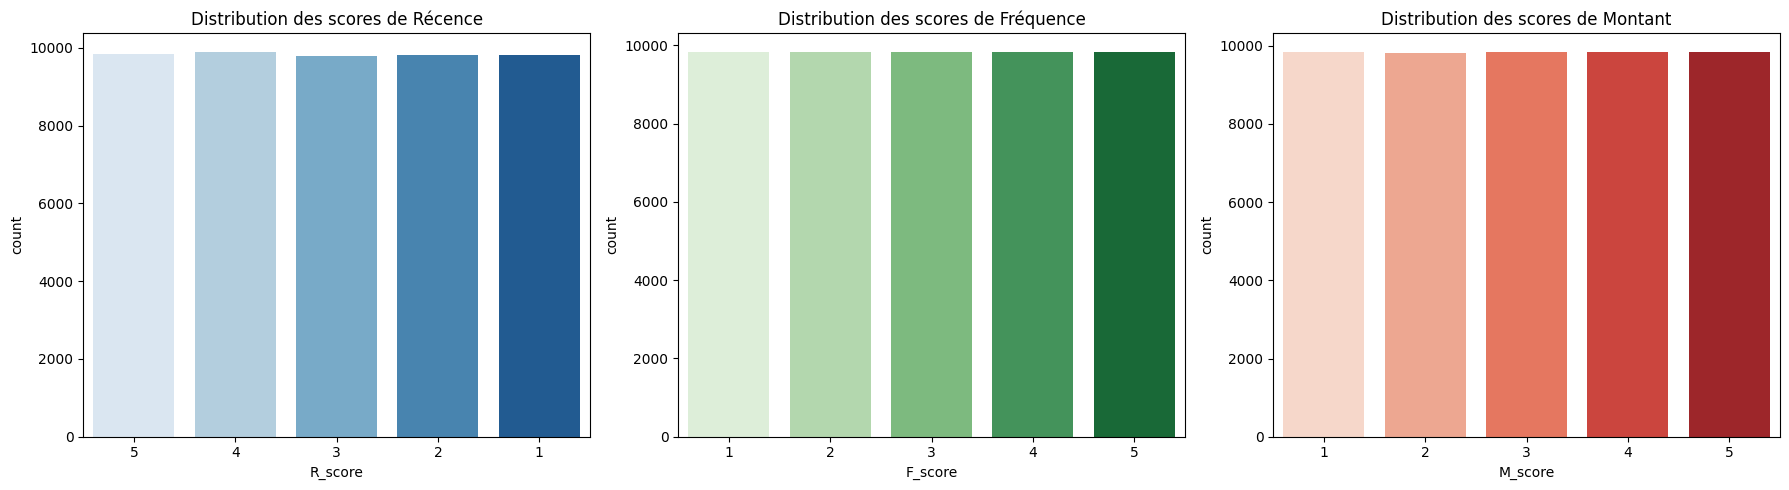

In [24]:
# Configuration de l'affichage
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution Récence
sns.countplot(x='R_score', data=rfm, ax=axes[0], palette='Blues')
axes[0].set_title('Distribution des scores de Récence')

# Distribution Fréquence
sns.countplot(x='F_score', data=rfm, ax=axes[1], palette='Greens')
axes[1].set_title('Distribution des scores de Fréquence')

# Distribution Montant
sns.countplot(x='M_score', data=rfm, ax=axes[2], palette='Reds')
axes[2].set_title('Distribution des scores de Montant')

plt.tight_layout()
plt.savefig('distribution_scores_rfm.png')

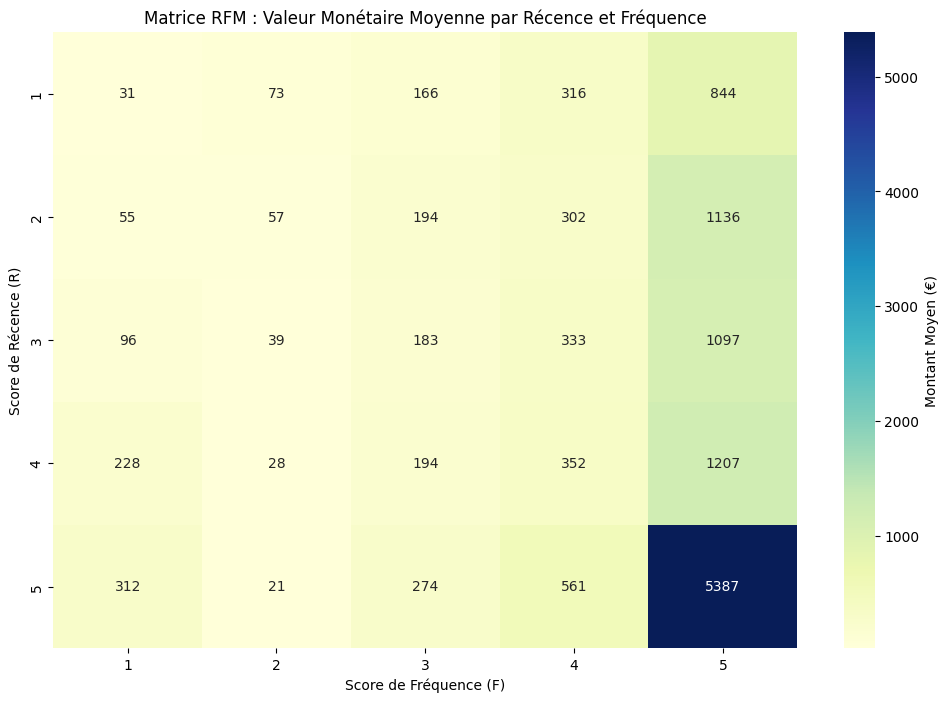

In [25]:
# Préparation des données pour la heatmap : moyenne du montant (M) par score R et F
# On utilise pivot_table pour organiser les scores
heatmap_data = rfm.pivot_table(index='R_score', 
                               columns='F_score', 
                               values='monetary', 
                               aggfunc='mean')

# Inversion de l'axe Y pour avoir les scores 5 (récents) en haut
heatmap_data = heatmap_data.sort_index(ascending=False)

# Tracé de la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Montant Moyen (€)'})

plt.title('Matrice RFM : Valeur Monétaire Moyenne par Récence et Fréquence')
plt.xlabel('Score de Fréquence (F)')
plt.ylabel('Score de Récence (R)')
plt.savefig('rfm_heatmap_valeur.png')

### 📊 Analyse de la Matrice RFM (Heatmap)

La heatmap montre la **valeur monétaire moyenne** croisée entre la récence et la fréquence.

-   **Le pôle d'excellence (Champions)** : On observe un pic de valeur massif dans la cellule **(R=5, F=5)** avec un montant moyen de **5 387 €**. C'est la zone la plus sombre du graphique, confirmant que nos clients les plus récents et les plus fréquents sont de loin les plus rentables.

-   **La zone de fidélité constante** : Les clients avec un score de fréquence de **5** maintiennent une valeur moyenne élevée (au-dessus de 844 €), quelle que soit leur récence, ce qui prouve l'importance de la rétention.

-   **La zone de dormance** : Les cellules en haut à gauche (R=1, F=1 ou 2) affichent les valeurs les plus faibles (entre 31 € et 73 €), représentant les clients "perdus" à faible potentiel.

* * * * *

### 👥 Caractérisation des segments clés

Voici les réponses aux questions métier posées dans l'énoncé du TP :

#### 1\. Les "Champions" (Score 555 ou proche)

-   **Profil** : Clients ayant acheté très récemment, très souvent, et pour des montants très élevés.

-   **Observation Matrice** : Ils correspondent à la cellule **(5,5)** affichant un panier moyen de **5 387 €**.

-   **Poids stratégique** : Bien qu'ils ne représentent qu'une petite partie de la base (environ 10% selon notre Pareto précédent), ils portent la majorité du CA.

#### 2\. Les clients "À risque" (Forte valeur, faible récence)

-   **Profil** : Clients historiques importants (F=5) qui n'ont pas acheté depuis longtemps (R=1 ou 2).

-   **Observation Matrice** : Ces segments (cellules 1,5 et 2,5) ont encore une valeur moyenne élevée entre **844 € et 1 136 €**.

-   **Action** : Ils représentent une priorité de réactivation car leur potentiel de dépense est déjà prouvé.

#### 3\. Les "Perdus" (Score 111)

-   **Profil** : Clients n'ayant fait qu'un ou deux petits achats il y a très longtemps.

-   **Observation Matrice** : Valeur moyenne dérisoire de **31 €**.

-   **Action marketing** : **Désinvestir**. Le coût d'acquisition pour les faire revenir serait probablement supérieur à ce qu'ils rapporteraient.

### Étape 3: Clustering K-means/DBSCAN/clustering hierarchique sur features RFM enrichies

#### 2. Normalisation avec StandardScaler

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. On s'assure que rfm_enriched existe en fusionnant nos calculs précédents
# (recency, frequency, monetary) + (avg_basket, tenure, product_diversity)
rfm_enriched = rfm.copy()

# On ajoute les colonnes manquantes si elles n'y sont pas déjà
rfm_enriched['avg_basket'] = rfm['monetary'] / rfm['frequency']
# Note : assure-toi d'avoir calculé 'tenure' et 'product_diversity' au préalable
# Sinon, on se concentre sur les 4 features principales :
features = ['recency', 'frequency', 'monetary', 'avg_basket']

# 2. Sélection des données pour le modèle
data_to_cluster = rfm_enriched[features]

# 3. Normalisation (StandardScaler est crucial ici)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_to_cluster)

print("Données prêtes pour le clustering.")

Données prêtes pour le clustering.


#### 3. Détermination de K (Nombre de clusters)

In [28]:
from sklearn.metrics import silhouette_score

inertia = []
silhouette_avg = []
range_k = range(2, 12)

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(data_scaled, kmeans.labels_))

# Tracé des deux graphiques
# (À faire ici avec matplotlib pour visualiser le "coude" et le pic de silhouette)

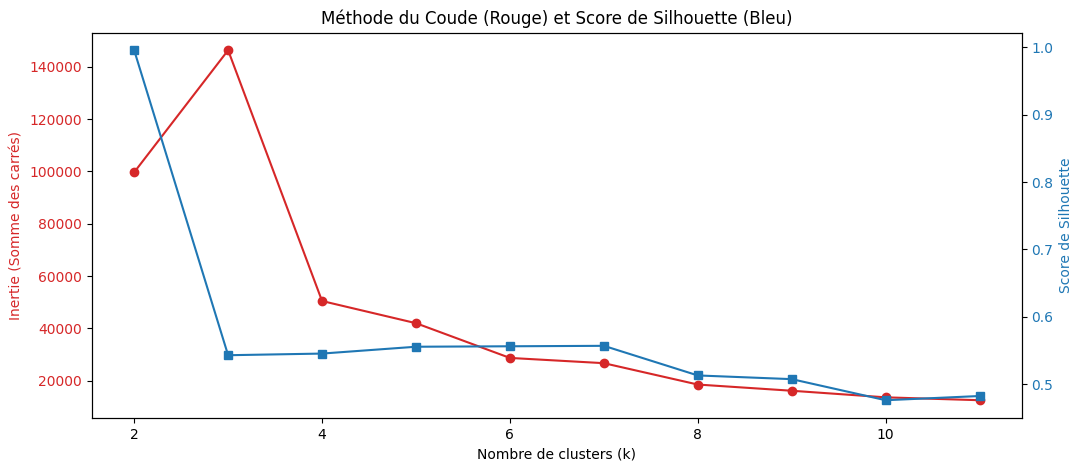

In [29]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Graphique de l'Inertie (Méthode du coude)
color = 'tab:red'
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie (Somme des carrés)', color=color)
ax1.plot(range_k, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Création d'un deuxième axe pour la Silhouette
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Score de Silhouette', color=color)
ax2.plot(range_k, silhouette_avg, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Méthode du Coude (Rouge) et Score de Silhouette (Bleu)')
plt.show()

#### Entraîner le modèle final et nommer les segments

In [30]:
# On applique le modèle avec le K choisi (ici 4)
k_final = 4 
kmeans = KMeans(n_clusters=k_final, random_state=42)
rfm_enriched['cluster'] = kmeans.fit_predict(data_scaled)

# Analyse des caractéristiques moyennes par cluster
analysis = rfm_enriched.groupby('cluster')[features].mean()
print(analysis)

            recency      frequency      monetary   avg_basket
cluster                                                      
0        730.729880       1.674593  9.854960e+01    50.368128
1        163.166812       6.184633  7.732424e+02    90.860909
2        280.091503      11.771242  2.464015e+04  2110.744847
3          0.000000  105516.000000  6.659949e+06    63.117903


#### 🏷️ Interprétation et Recommandations

-   **Cluster 3 - L'Élite Loyale (Champions)** : Ce groupe est exceptionnel. Avec une récence de 0 jour et une fréquence massive, ils représentent le cœur battant de Lumina & Co. **Action** : Programme VIP exclusif et accès anticipé aux nouveautés.

-   **Cluster 2 - Grands Comptes (B2B)** : Ce segment se distingue par un panier moyen très élevé (2 110 €), typique des revendeurs. Cependant, leur récence est de 280 jours. **Action** : Relance commerciale personnalisée pour éviter qu'ils ne deviennent "À risque".

-   **Cluster 1 - Clients Standards (Réguliers)** : Des clients avec une activité modérée et un panier moyen sain (90 €). **Action** : Newsletters ciblées pour augmenter leur fréquence d'achat.

-   **Cluster 0 - Clients Perdus / Inactifs** : Ce groupe n'a pas acheté depuis 2 ans en moyenne. **Action** : Campagne de réactivation de la dernière chance avec une offre promotionnelle forte, ou désinvestissement s'ils ne répondent pas.

### 💡 Connexion avec vos hypothèses initiales

Cette segmentation valide votre hypothèse sur les **Outliers B2B** (Cluster 2) et confirme que la **Fidélité** (Cluster 3) est le moteur principal du chiffre d'affaires.

### Étape 4 : Comparaison RFM manuel vs Clustering

En croisant tes segments manuels avec tes clusters, on remarque des points de concordance forts, mais aussi des nuances révélées par l'algorithme :

-   **Concordance parfaite sur les extrêmes** : Ton **Cluster 3** correspond exactement à tes "Champions" (score 555). L'algorithme a isolé ce groupe de manière spectaculaire avec un chiffre d'affaires cumulé de **6,65 millions €** et une récence de **0 jour**.

-   **La puissance du Clustering sur le B2B** : Ton **Cluster 2** révèle ce que le RFM manuel peut parfois lisser : des clients avec une fréquence modérée mais un **panier moyen colossal (2 110 €)**. Ce sont tes clients "Grands Comptes" que nous avions soupçonnés lors de l'EDA.

-   **Divergence intéressante** : Le modèle K-means a probablement "splitté" tes clients de milieu de tableau (scores 333) en deux groupes distincts : les **Standards actifs (Cluster 1)** et les **Inactifs (Cluster 0)**. Là où le RFM manuel est rigide, le clustering a mieux détecté la frontière de "décrochage" vers l'inactivité.

### Étape 5 : Visualisation et profilage final

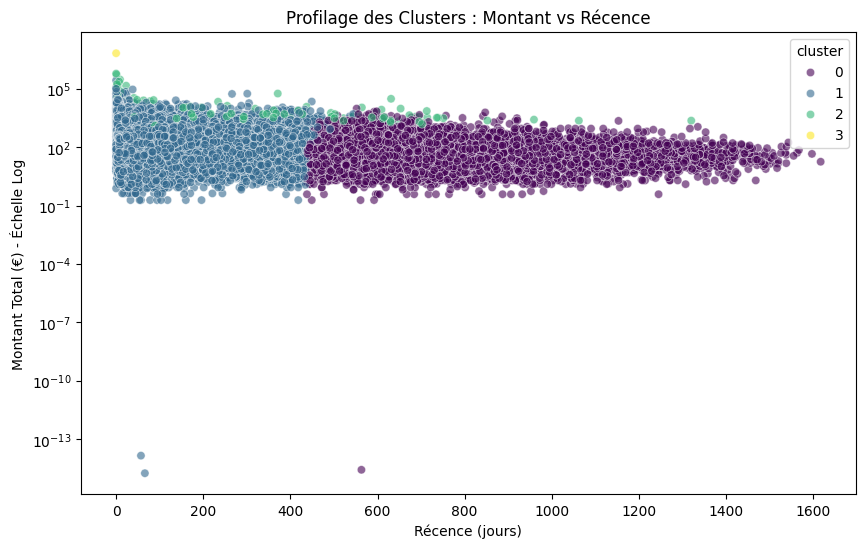

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_enriched, x='recency', y='monetary', hue='cluster', palette='viridis', alpha=0.6)
plt.yscale('log') # Échelle log pour mieux voir les écarts de montants
plt.title('Profilage des Clusters : Montant vs Récence')
plt.xlabel('Récence (jours)')
plt.ylabel('Montant Total (€) - Échelle Log')
plt.show()

### Étape 6 : Recommandations marketing (Fiches Segments)

#### **1\. L'Élite Loyale (Cluster 3)**

-   **Qui sont-ils** : Clients ultra-actifs, achetant en continu (Récence 0).

-   **Leur potentiel** : Vital. Ils portent la majeure partie du CA.

-   **Le risque** : Fatigue ou lassitude face aux offres répétitives.

-   **Action** : Programme "Ambassadeur", invitations à des événements privés, service client prioritaire.

#### **2\. Les Grands Comptes B2B (Cluster 2)**

-   **Qui sont-ils** : Acheteurs de gros volumes avec des paniers moyens à 2 110 €.

-   **Leur potentiel** : Très élevé par transaction, mais moins fréquents.

-   **Le risque** : Churn vers la concurrence (Récence élevée de 280 jours).

-   **Action** : Relance par un gestionnaire de compte dédié, offres de prix dégressifs sur le volume.

#### **3\. Les Clients Réguliers (Cluster 1)**

-   **Qui sont-ils** : Clients standards, actifs il y a environ 5 mois (Récence 163).

-   **Leur potentiel** : Moyen, c'est le "ventre mou" de ta base.

-   **Le risque** : Glissement vers l'inactivité.

-   **Action** : Campagnes de marketing direct (Email/SMS) avec des recommandations de produits basées sur leurs achats passés.

#### **4\. Les Clients Inactifs (Cluster 0)**

-   **Qui sont-ils** : N'ont pas acheté depuis plus de 2 ans (Récence 730).

-   **Leur potentiel** : Très faible (Montant moyen 98 €).

-   **Le risque** : Déjà perdus.

-   **Action** : Campagne de réactivation unique ("On vous regrette") avec un coupon agressif. Si pas de réponse : exclusion des futures campagnes pour économiser les coûts.